In [1]:
%pip install -U pip
%pip install torch==2.6.0 torchvision==0.21.0 torchaudio==2.6.0
%pip install opencv-python-headless scikit-learn tqdm
%pip install git+https://github.com/Atze00/MoViNet-pytorch.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 33.3 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 766.6/766.6 MB 16.1 MB/s  0:00:21m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 122.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 99.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 60.6 MB/s  0:00:04m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 157.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 163.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 15.8 MB/s  0:00:20m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 74.1 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
from pathlib import Path
import random

from google.colab import drive

import cv2
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

from movinets import MoViNet
from movinets.config import _C

drive.mount("/content/drive", force_remount=True)

SEED = 42
NUM_FRAMES = 16
IMAGE_SIZE = 172
BATCH_SIZE = 8
NUM_WORKERS = 2
NUM_EPOCHS = 5
LR = 1e-4
MODEL_NAME = "A0"
CLASS_NAMES = ["NonViolence", "Violence"]

DRIVE_ROOT = Path("/content/drive/MyDrive")
SERVICE_ROOT = DRIVE_ROOT / "IT" / "Dataset"
DATASET_ZIP_PATH = SERVICE_ROOT / "real-life-violence-dataset.zip"
ROOT = Path("/content/real-life-violence-dataset")
CHECKPOINT_PATH = SERVICE_ROOT / "movinet_a0_violence.pt"

assert DATASET_ZIP_PATH.exists(), f"Dataset zip not found: {DATASET_ZIP_PATH}"
CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Dataset zip:", DATASET_ZIP_PATH.resolve())
print("Extracted dataset root:", ROOT)
print("Checkpoint path:", CHECKPOINT_PATH.resolve())

Mounted at /content/drive
Device: cuda
Dataset zip: /content/drive/MyDrive/IT/Dataset/real-life-violence-dataset.zip
Extracted dataset root: /content/real-life-violence-dataset
Checkpoint path: /content/drive/MyDrive/IT/Dataset/movinet_a0_violence.pt


In [3]:
!unzip -qo "{DATASET_ZIP_PATH}" -d /content/

assert ROOT.exists(), f"Extracted dataset directory not found: {ROOT}"
for class_name in CLASS_NAMES:
    class_dir = ROOT / class_name
    assert class_dir.exists(), f"Missing class directory: {class_dir}"

print("Dataset extracted and verified at:", ROOT)

Dataset extracted and verified at: /content/real-life-violence-dataset


In [4]:
from pathlib import Path
from sklearn.model_selection import train_test_split

def collect_samples(root):
    root = Path(root)
    samples = []
    label_map = {"NonViolence": 0, "Violence": 1}
    valid_exts = {".mp4", ".avi", ".mov", ".mkv"}

    for class_name, label in label_map.items():
        class_dir = root / class_name
        if not class_dir.exists():
            continue
        for path in class_dir.iterdir():
            if path.suffix.lower() in valid_exts and path.is_file():
                samples.append((str(path), label))
    return samples

samples = collect_samples(ROOT)
if len(samples) == 0:
    raise RuntimeError(f"Cannot find any video files in {ROOT}")

labels = [s[1] for s in samples]
train_samples, val_samples = train_test_split(
    samples,
    test_size=0.2,
    random_state=SEED,
    stratify=labels,
)
train_samples = random.sample(train_samples, 400)
val_samples = random.sample(val_samples, 100)

print(f"Total: {len(samples)} | Train: {len(train_samples)} | Val: {len(val_samples)}")

Total: 2000 | Train: 400 | Val: 100


In [5]:
KINETICS_MEAN = np.array([0.43216, 0.394666, 0.37645], dtype=np.float32).reshape(1, 1, 1, 3)
KINETICS_STD = np.array([0.22803, 0.22145, 0.216989], dtype=np.float32).reshape(1, 1, 1, 3)

def read_video_clip(video_path: str, num_frames: int, image_size: int, augment: bool = False):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Cannot open video: {video_path}")

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if frame_count <= 0:
        cap.release()
        raise ValueError(f"No frames in video: {video_path}")

    indices = np.linspace(0, frame_count - 1, num=num_frames, dtype=np.int32)
    frames = []

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ok, frame = cap.read()
        if not ok or frame is None:
            continue
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frame = cv2.resize(frame, (image_size, image_size), interpolation=cv2.INTER_AREA)
        frames.append(frame.astype(np.float32) / 255.0)

    cap.release()

    if len(frames) == 0:
        raise ValueError(f"Cannot read any frames from: {video_path}")

    while len(frames) < num_frames:
        frames.append(frames[-1].copy())

    frames = frames[:num_frames]
    arr = np.stack(frames, axis=0)

    if augment and np.random.rand() < 0.5:
        arr = arr[:, :, ::-1, :].copy()

    arr = (arr - KINETICS_MEAN) / KINETICS_STD
    arr = np.transpose(arr, (3, 0, 1, 2))
    arr = np.ascontiguousarray(arr)
    return torch.from_numpy(arr).float()

class ViolenceDataset(Dataset):
    def __init__(self, samples, num_frames=16, image_size=172, augment=False):
        self.samples = samples
        self.num_frames = num_frames
        self.image_size = image_size
        self.augment = augment

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        clip = read_video_clip(path, self.num_frames, self.image_size, self.augment)
        return clip, torch.tensor(label, dtype=torch.long)

In [6]:
train_dataset = ViolenceDataset(train_samples, num_frames=NUM_FRAMES, image_size=IMAGE_SIZE, augment=True)
val_dataset = ViolenceDataset(val_samples, num_frames=NUM_FRAMES, image_size=IMAGE_SIZE, augment=False)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=NUM_WORKERS > 0,
    drop_last=False,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=NUM_WORKERS > 0,
    drop_last=False,
)

print("Train batches:", len(train_loader), "| Val batches:", len(val_loader))
print("DataLoader workers:", NUM_WORKERS)

Train batches: 50 | Val batches: 13
DataLoader workers: 2


In [7]:
def build_model_a0_binary():
    # Build model with 2 classes and tf_like=True, then load pretrained weights where shapes match.
    model = MoViNet(
        _C.MODEL.MoViNetA0,
        causal=False,
        pretrained=False,
        num_classes=2,
        conv_type="3d",
        tf_like=True,
    )

    pretrained_model = MoViNet(_C.MODEL.MoViNetA0, causal=False, pretrained=True)
    pretrained_state = pretrained_model.state_dict()
    target_state = model.state_dict()

    compatible = {
        k: v
        for k, v in pretrained_state.items()
        if k in target_state and target_state[k].shape == v.shape
    }
    target_state.update(compatible)
    model.load_state_dict(target_state)
    return model


def freeze_backbone_train_head_only(model: nn.Module):
    for param in model.parameters():
        param.requires_grad = False

    trainable_names = []
    for name, param in model.named_parameters():
        lname = name.lower()
        if "classifier" in lname or "head" in lname:
            param.requires_grad = True
            trainable_names.append(name)

    if not trainable_names:
        raise RuntimeError("Cannot find classifier/head parameters to train.")

    print("Trainable layers (head only):")
    for name in trainable_names:
        print(" -", name)


model = build_model_a0_binary().to(device)
freeze_backbone_train_head_only(model)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR,
    weight_decay=1e-4,
)
print("Model ready (backbone frozen, classifier/head trainable).")

Downloading: "https://github.com/Atze00/MoViNet-pytorch/blob/main/weights/modelA0_statedict_v3?raw=true" to /root/.cache/torch/hub/checkpoints/modelA0_statedict_v3
100%|██████████| 12.1M/12.1M [00:00<00:00, 174MB/s]


Trainable layers (head only):
 - classifier.0.conv_1.conv3d.weight
 - classifier.0.conv_1.conv3d.bias
 - classifier.3.conv_1.conv3d.weight
 - classifier.3.conv_1.conv3d.bias
Model ready (backbone frozen, classifier/head trainable).


In [8]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    pbar = tqdm(loader, desc="train", leave=False)
    for clips, labels in pbar:
        clips = clips.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(clips)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        preds = logits.argmax(dim=1)
        running_loss += loss.item() * labels.size(0)
        running_correct += (preds == labels).sum().item()
        running_total += labels.size(0)

    return running_loss / running_total, running_correct / running_total

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    running_total = 0
    all_targets = []
    all_preds = []

    pbar = tqdm(loader, desc="val", leave=False)
    for clips, labels in pbar:
        clips = clips.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(clips)
        loss = criterion(logits, labels)

        preds = logits.argmax(dim=1)
        running_loss += loss.item() * labels.size(0)
        running_correct += (preds == labels).sum().item()
        running_total += labels.size(0)

        all_targets.extend(labels.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())

    return (
        running_loss / running_total,
        running_correct / running_total,
        np.array(all_targets),
        np.array(all_preds),
    )

In [9]:
best_val_acc = -1.0
best_state = None
history = []

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, y_true, y_pred = evaluate(model, val_loader, criterion, device)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
    })

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} train_acc={train_acc:.4f} | val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        
        torch.save(
            {
                "state_dict": model.state_dict(),
                "class_names": CLASS_NAMES,
                "num_classes": len(CLASS_NAMES),
                "model_name": MODEL_NAME,
                "num_frames": NUM_FRAMES,
                "image_size": IMAGE_SIZE,
                "epoch": epoch,
            },
            CHECKPOINT_PATH,
        )

print("Best val acc:", best_val_acc)

train:   0%|          | 0/50 [00:00<?, ?it/s]

val:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 01 | train_loss=1.6881 train_acc=0.7050 | val_loss=0.5566 val_acc=0.8500


train:   0%|          | 0/50 [00:00<?, ?it/s]

val:   0%|          | 0/13 [00:00<?, ?it/s]

...

val:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 04 | train_loss=0.5857 train_acc=0.8775 | val_loss=0.7004 val_acc=0.8700


train:   0%|          | 0/50 [00:00<?, ?it/s]

val:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 05 | train_loss=0.3833 train_acc=0.9125 | val_loss=0.3943 val_acc=0.8800
Best val acc: 0.89


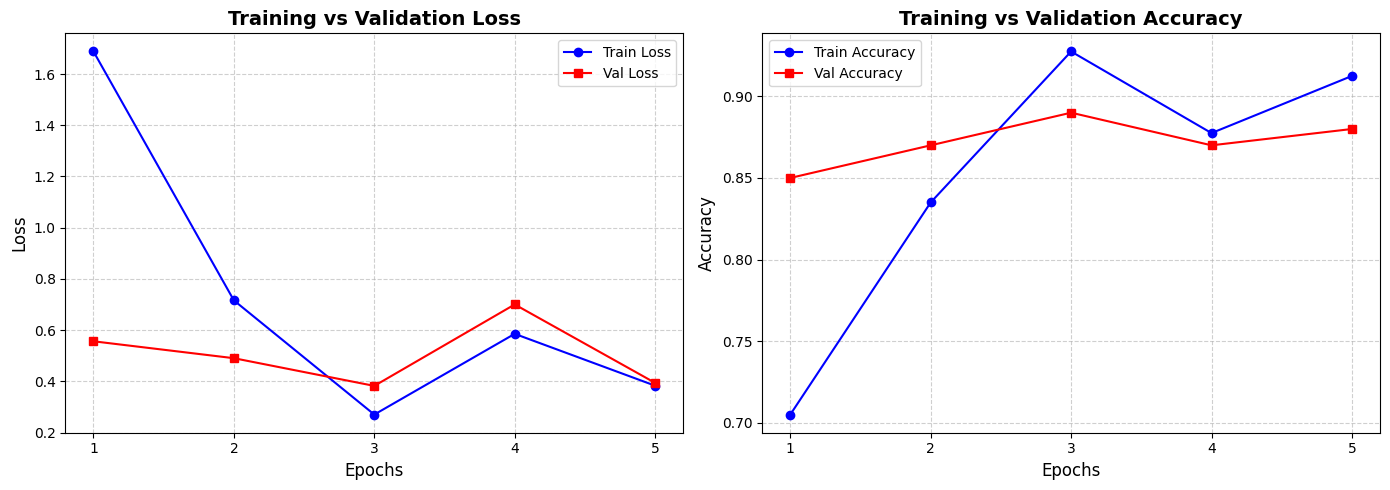

In [10]:
import matplotlib.pyplot as plt

epochs = [x['epoch'] for x in history]
train_loss = [x['train_loss'] for x in history]
val_loss = [x['val_loss'] for x in history]
train_acc = [x['train_acc'] for x in history]
val_acc = [x['val_acc'] for x in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Loss Diagram
ax1.plot(epochs, train_loss, label='Train Loss', color='blue', marker='o')
ax1.plot(epochs, val_loss, label='Val Loss', color='red', marker='s')
ax1.set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_xticks(epochs)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# 2. Accuracy Diagram
ax2.plot(epochs, train_acc, label='Train Accuracy', color='blue', marker='o')
ax2.plot(epochs, val_acc, label='Val Accuracy', color='red', marker='s')
ax2.set_title('Training vs Validation Accuracy', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_xticks(epochs)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [11]:
model.load_state_dict(best_state)
val_loss, val_acc, y_true, y_pred = evaluate(model, val_loader, criterion, device)
print("Validation accuracy:", round(val_acc, 4))
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))
print("Confusion matrix:")
print(confusion_matrix(y_true, y_pred))

val:   0%|          | 0/13 [00:00<?, ?it/s]

Validation accuracy: 0.89
              precision    recall  f1-score   support

 NonViolence     0.8983    0.9138    0.9060        58
    Violence     0.8780    0.8571    0.8675        42

    accuracy                         0.8900       100
   macro avg     0.8882    0.8855    0.8867       100
weighted avg     0.8898    0.8900    0.8898       100

Confusion matrix:
[[53  5]
 [ 6 36]]


In [12]:
checkpoint_path = CHECKPOINT_PATH
torch.save(
    {
        "state_dict": model.state_dict(),
        "class_names": CLASS_NAMES,
        "num_classes": len(CLASS_NAMES),
        "model_name": MODEL_NAME,
        "num_frames": NUM_FRAMES,
        "image_size": IMAGE_SIZE,
    },
    checkpoint_path,
)
print(f"Saved checkpoint to: {checkpoint_path.resolve()}")

Saved checkpoint to: /content/drive/MyDrive/IT/Dataset/movinet_a0_violence.pt


In [13]:
@torch.no_grad()
def predict_video(model, video_path: str, num_frames=16, image_size=172):
    model.eval()
    clip = read_video_clip(video_path, num_frames, image_size, augment=False).unsqueeze(0).to(device)
    logits = model(clip)
    probs = torch.softmax(logits, dim=1)[0].cpu().numpy()
    pred_idx = int(np.argmax(probs))
    return CLASS_NAMES[pred_idx], float(probs[1]), probs

sample_path = train_samples[0][0]
label, violence_score, probs = predict_video(model, sample_path, NUM_FRAMES, IMAGE_SIZE)
print("Sample:", sample_path)
print("Pred label:", label)
print("Violence score:", round(violence_score, 4))
print("Probabilities:", probs)

Sample: /content/real-life-violence-dataset/Violence/V_473.mp4
Pred label: Violence
Violence score: 0.9976
Probabilities: [0.00243007 0.99756986]
